In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict


In [11]:
with open('results/UG_results.json', 'r') as file:
    second_dataset = json.load(file)
UG_s_data = second_dataset.get("S", None)


# Initialize a dictionary to accumulate scenario-level sums
scenario_sums = defaultdict(float)

# Loop over the nested structure S[antigen][year][scenario]
for antigen_dict in UG_s_data.values():
    for year_dict in antigen_dict.values():
        for scenario, value in year_dict.items():
            scenario_sums[scenario] += value

# Convert the result to a DataFrame for display
UG_scenario_sum_df = pd.DataFrame(list(scenario_sums.items()), columns=["Scenario", "Total_Value"]).sort_values("Scenario")


In [14]:
with open('results/SB_results.json', 'r') as file:
    second_dataset = json.load(file)
SB_s_data = second_dataset.get("S", None)


# Initialize a dictionary to accumulate scenario-level sums
scenario_sums = defaultdict(float)

# Loop over the nested structure S[antigen][year][scenario]
for antigen_dict in SB_s_data.values():
    for year_dict in antigen_dict.values():
        for scenario, value in year_dict.items():
            scenario_sums[scenario] += value

# Convert the result to a DataFrame for display
SB_scenario_sum_df = pd.DataFrame(list(scenario_sums.items()), columns=["Scenario", "Total_Value"]).sort_values("Scenario")

In [15]:
with open('results/MP_results.json', 'r') as file:
    second_dataset = json.load(file)
MP_s_data = second_dataset.get("S", None)


# Initialize a dictionary to accumulate scenario-level sums
scenario_sums = defaultdict(float)

# Loop over the nested structure S[antigen][year][scenario]
for antigen_dict in MP_s_data.values():
    for year_dict in antigen_dict.values():
        for scenario, value in year_dict.items():
            scenario_sums[scenario] += value

# Convert the result to a DataFrame for display
MP_scenario_sum_df = pd.DataFrame(list(scenario_sums.items()), columns=["Scenario", "Total_Value"]).sort_values("Scenario")

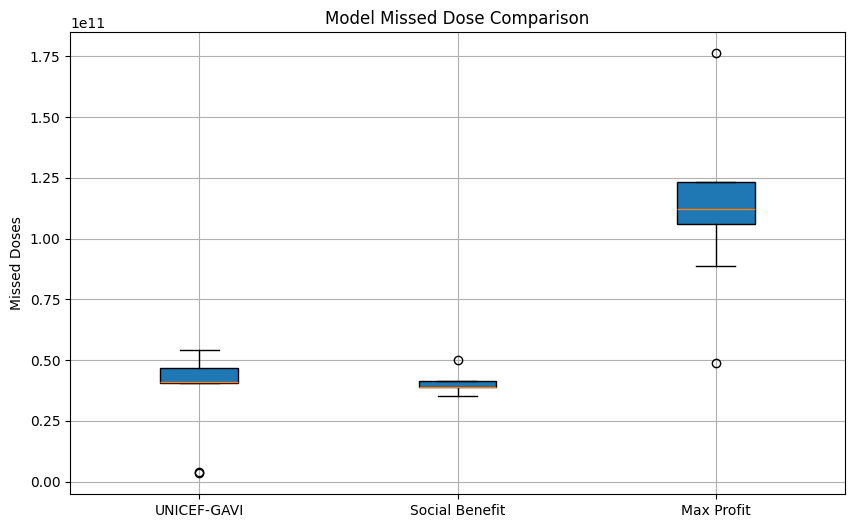

In [25]:


# Combine both datasets into a DataFrame for plotting
combined_data = pd.DataFrame({
    'Scenario': UG_scenario_sum_df['Scenario'],
    'Dataset 1': UG_scenario_sum_df['Total_Value'],
    'Dataset 2': SB_scenario_sum_df['Total_Value'].values,
    'Dataset 3': MP_scenario_sum_df['Total_Value'].values
})

combined_data["Dataset 1"] *= 1000

# Create a double box plot for the two datasets
plt.figure(figsize=(10, 6))
plt.boxplot([combined_data['Dataset 1'], combined_data['Dataset 2'], combined_data['Dataset 3']], labels=['UNICEF-GAVI', 'Social Benefit', 'Max Profit'], patch_artist=True)
plt.title('Model Missed Dose Comparison')
plt.ylabel('Missed Doses')
plt.grid(True)
plt.savefig('model_triad_missed_dose_comparison.jpg', bbox_inches='tight', pad_inches=0.1, dpi=600)
plt.show()


In [23]:
combined_data

,Scenario,Dataset 1,Dataset 2,Dataset 3
7,1,3.397941e+06,4.082001e+10,1.076054e+11
3,10,4.099649e+07,4.122128e+10,8.872189e+10
2,11,3.727485e+06,3.537228e+10,1.762623e+11
6,17,4.661666e+07,3.541631e+10,1.233178e+11
8,19,5.398870e+07,3.898522e+10,1.233638e+11
4,26,4.038396e+07,3.902560e+10,1.060186e+11
5,30,4.107420e+07,3.886577e+10,4.865607e+10
1,35,4.673925e+07,5.010131e+10,1.232649e+11
0,4,4.657471e+07,4.121460e+10,1.119866e+11
